# Mapping the Parks

Using data from [nycopendata](https://nycopendata.socrata.com/Recreation/Parks-Properties/enfh-gkve/about_data), specifically the `shape` column, let's see if we can create map visualizations.

In [1]:
import datetime
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.eda import COLORS, COLORS_DICT, get_parks_data, PARKS_MAPPING, nymyc_cmap, nymyc_cmap_r, read_all_csvs

# mpl.colormaps.register(cmap=nymyc_cmap)
# mpl.colormaps.register(cmap=nymyc_cmap_r)
# nymyc_palette = sns.set_palette(sns.color_palette(COLORS))

# Show all columns in DataFrames
pd.set_option('display.max_columns', None)

# Auto-reload modules
%load_ext autoreload
%autoreload 2

<Axes: >

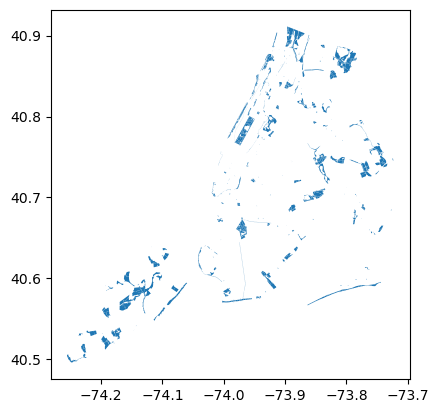

In [2]:
parks = gpd.read_file('../data/Parks Zones_20241027/')
parks.plot()

Got it plotting! But definitely need borough boundaries or something else in the background--can't just have parks floating in space.

<Axes: >

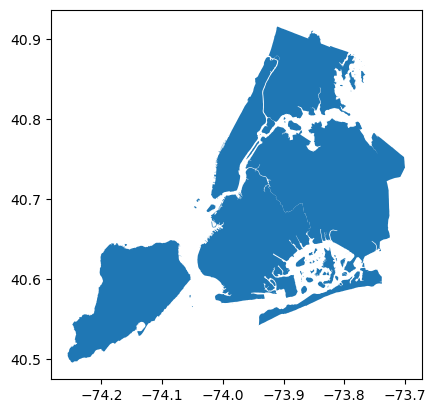

In [3]:
boroughs = gpd.read_file('../data/Borough Boundaries/')
boroughs.plot()

Now to combine them...

<Axes: >

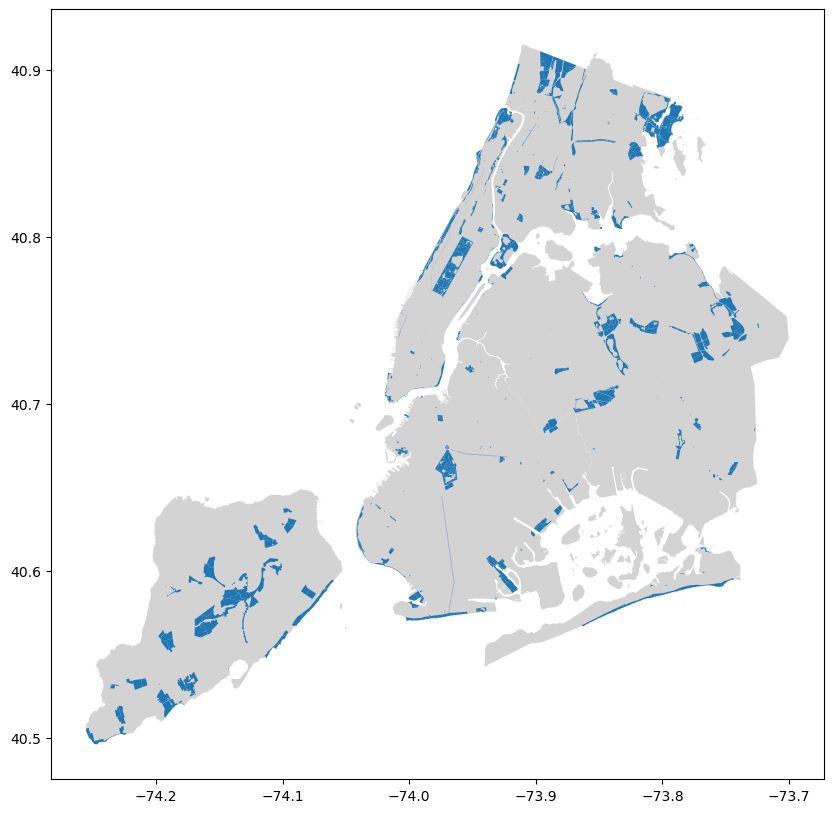

In [4]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks.plot(ax=ax)

Need to add in Green-Wood and Woodlawn Cemeteries.

In [73]:
cemeteries = gpd.read_file('../data/2020_Neighborhood_Tabulation_Areas__NTAs__20241127.csv')
cemeteries = cemeteries.loc[(cemeteries['NTAName'] == 'Green-Wood Cemetery') | (cemeteries['NTAName'] == 'Woodlawn Cemetery')][['the_geom','BoroName','NTAName']]
cemeteries

,the_geom,BoroName,NTAName
25,MULTIPOLYGON (((-73.98843135252152 40.65925121...,Brooklyn,Green-Wood Cemetery
114,MULTIPOLYGON (((-73.87406751271385 40.88003890...,Bronx,Woodlawn Cemetery


In [74]:
# Prep cemeteries data to append to parks data
cemeteries['BoroName'] = cemeteries['BoroName'].map({v: k for k, v in PARKS_MAPPING.items()})
cemeteries = cemeteries.rename(columns={'BoroName':'borough', 'NTAName':'propname','the_geom':'geometry'})
cemeteries

,geometry,borough,propname
25,MULTIPOLYGON (((-73.98843135252152 40.65925121...,B,Green-Wood Cemetery
114,MULTIPOLYGON (((-73.87406751271385 40.88003890...,X,Woodlawn Cemetery


In [75]:
parks = parks[['borough', 'propname', 'geometry']]
parks.head()

,borough,propname,geometry
0,M,Central Park,"POLYGON ((-73.95686 40.79685, -73.95683 40.796..."
1,M,Central Park,"POLYGON ((-73.95386 40.79063, -73.95389 40.790..."
2,M,Central Park,"POLYGON ((-73.96174 40.79158, -73.96172 40.791..."
3,M,Central Park,"POLYGON ((-73.96932 40.78429, -73.96926 40.784..."
4,M,Central Park,"POLYGON ((-73.96320 40.78286, -73.96325 40.782..."


In [78]:
parks = pd.concat([parks,cemeteries])

Success! Now to get some data in there...

In [79]:
parks_data = get_parks_data()
parks_data.head()

,MushroomID,NewToPark,NewToCity,ParkName,Borough,City,State,BroadGroupID,Genus,Species,BroadGroupName,FullName
0,300,y,y,Central Park,Manhattan,New York City,NY,3.0,Hortiboletus,campestris,Boletes,Hortiboletus campestris
1,2329,y,y,Central Park,Manhattan,New York City,NY,3.0,Boletus,subvelutipes-complex,Boletes,Boletus subvelutipes-complex
2,3,y,y,Central Park,Manhattan,New York City,NY,3.0,Cyanoboletus,pulverulentus,Boletes,Cyanoboletus pulverulentus
3,4,y,y,Central Park,Manhattan,New York City,NY,3.0,Gyroporus,castaneus,Boletes,Gyroporus castaneus
4,5,y,y,Central Park,Manhattan,New York City,NY,3.0,Tylopilus,ferrugineus,Boletes,Tylopilus ferrugineus


In [80]:
# Check for parks that don't match across datasets
nymyc_parks = list(parks_data['ParkName'].unique())
nymyc_parks.sort()
nyc_parks = list(parks['propname'].unique())
nyc_parks.sort()
print('Parks in walks list but not in NYC data:')
print([p for p in nymyc_parks if p not in nyc_parks])
print('\n')
print('Parks in NYC data but not in walks list:')
print([p for p in nyc_parks if p not in nymyc_parks])

Parks in walks list but not in NYC data:
['Beech Brook', 'Collis P. Huntingdon Park', 'Depew Park', "Devil's Den Preserve", 'Fahnestock State Park', 'High Rock Park', 'Manitou Point Preserve', 'Mt. Lakes Park', 'Norvin Green State Forest', 'Putnam Memorial State Park', 'South Mountain Reservation', 'Stony Brook, Harriman', 'Stony Brook, Long Island', 'Tallman State Park', 'Untermeyer Gardens', 'Wawayanda State Park']


Parks in NYC data but not in walks list:
['Alley Athletic Playground', 'Aqueduct Walk', 'Archie Spigner Park', 'Arden Woods', 'Asphalt Green', 'Asser Levy Park', 'Astoria Park', 'Bailey Playground', 'Baisley Pond Park', 'Battery Park City', 'Bayswater Park', 'Belt Parkway/Shore Parkway', 'Bensonhurst Park', 'Betsy Head Park', 'Blood Root Valley', 'Bloomingdale Park', 'Blue Heron Park', 'Bowne Park', 'Breukelen Ballfields', 'Broadway Malls', 'Bronx Park', 'Bronx River Parkway', 'Brookfield Park', 'Brooklyn Bridge Park', 'Brookville Park', 'Brower Park', 'CPL. Thompson Par

Looks like most of the parks from the walk list that aren't in NYC's data are, in fact, not in NYC. So no worries there. Others aren't NYC parks, like Woodlawn Cemetery.

The parks in NYC's data that aren't in the walks list are a lot of parks that just don't have walks (like Washington Sq Park).

There are some that just don't match up (like 'Randalls Island' vs 'Randall's Island Park' and 'Wolfe\\'s Pond Park' vs 'Wolfe's Pond Park'), so should clean those up. (Note: adding that to some of the cleaning functinality in `eda.py` that gets called whenever reading in the data.)

In [81]:
parks_counts = parks_data.groupby('ParkName')[['BroadGroupName','Species']].nunique().reset_index()
parks_counts = parks_counts.rename(columns={'BroadGroupName':'BroadGroupCounts',
                                            'Species':'SpeciesCounts'})
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts
0,Alley Pond Park,16,381
1,Beech Brook,17,386
2,Central Park,14,316
3,Clove Lakes Park,15,302
4,Collis P. Huntingdon Park,14,246
5,Conference House Park,2,2
6,Cunningham Park,15,364
7,Depew Park,12,185
8,Devil's Den Preserve,11,128
9,Fahnestock State Park,13,159


In [82]:
parks_viz = parks.merge(parks_counts, 
                        left_on='propname', right_on='ParkName', 
                        how='left')
parks_viz.head()

,borough,propname,geometry,ParkName,BroadGroupCounts,SpeciesCounts
0,M,Central Park,POLYGON ((-73.95685802260859 40.79685050312753...,Central Park,14.0,316.0
1,M,Central Park,POLYGON ((-73.95386057527419 40.79063428274346...,Central Park,14.0,316.0
2,M,Central Park,"POLYGON ((-73.9617385513246 40.79157692056822,...",Central Park,14.0,316.0
3,M,Central Park,"POLYGON ((-73.96932387651069 40.7842876763676,...",Central Park,14.0,316.0
4,M,Central Park,POLYGON ((-73.96320343009873 40.78286292563462...,Central Park,14.0,316.0


Interesting--many rows per park? Looks like multiple "zones" per park, but I bet that will show up in the viz as one contiguous area.

''

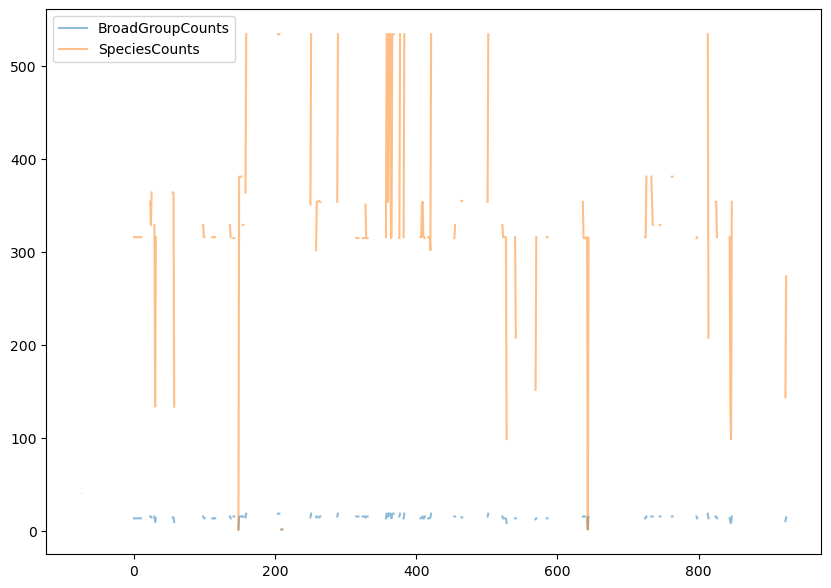

In [83]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='BroadGroupCounts', ax=ax,
                  legend=True, alpha=.5)
plt.savefig('./img/parks_groups_counts.png')
;

''

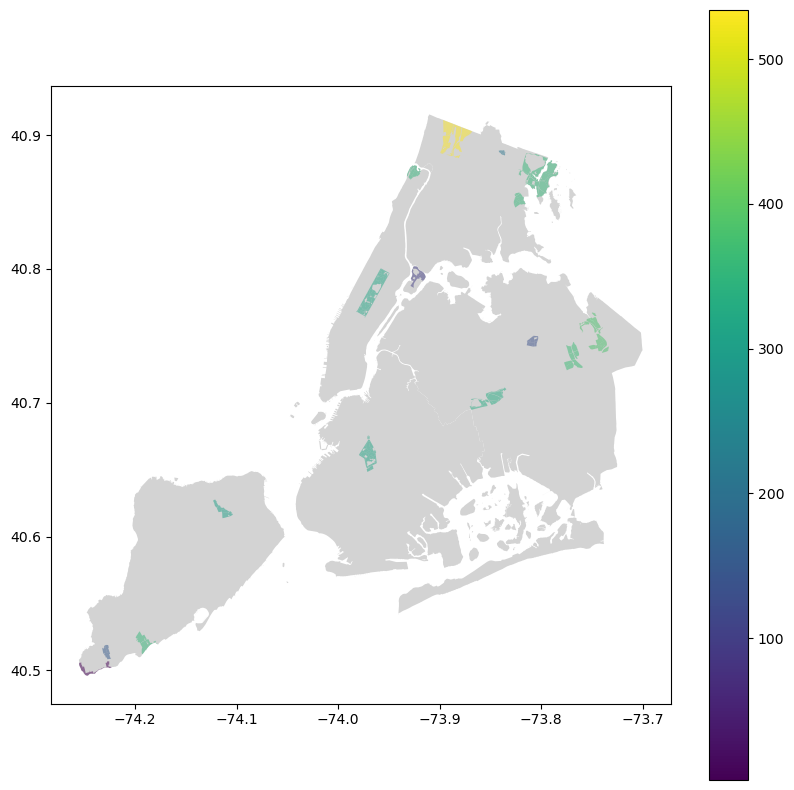

In [10]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='SpeciesCounts', ax=ax,
                  legend=True, alpha=.5)
plt.savefig('./img/parks_species_counts.png')
;

Let's try visualizing each park separately to get better resolution.

''

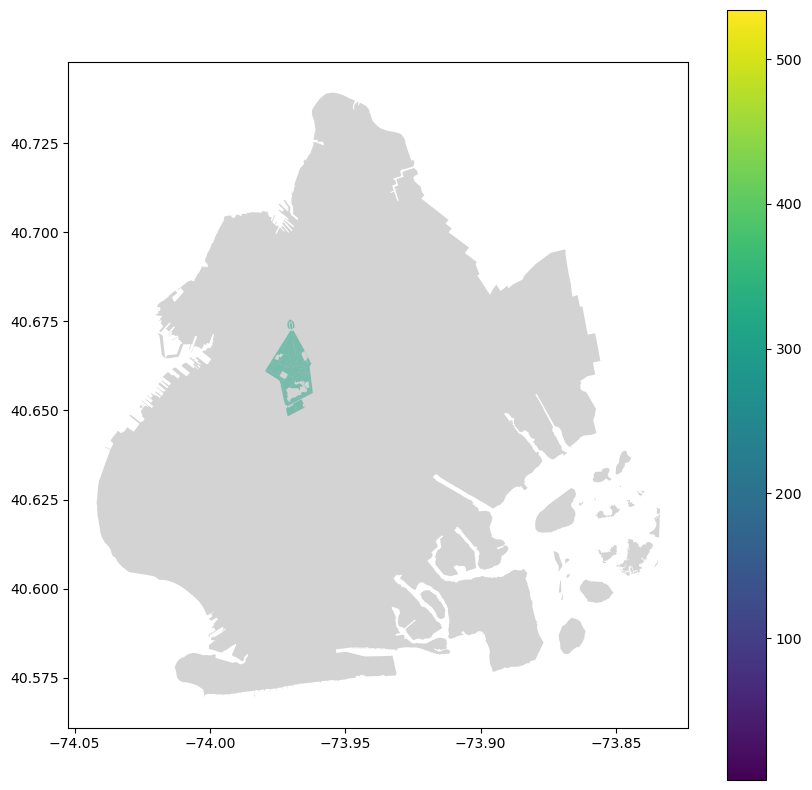

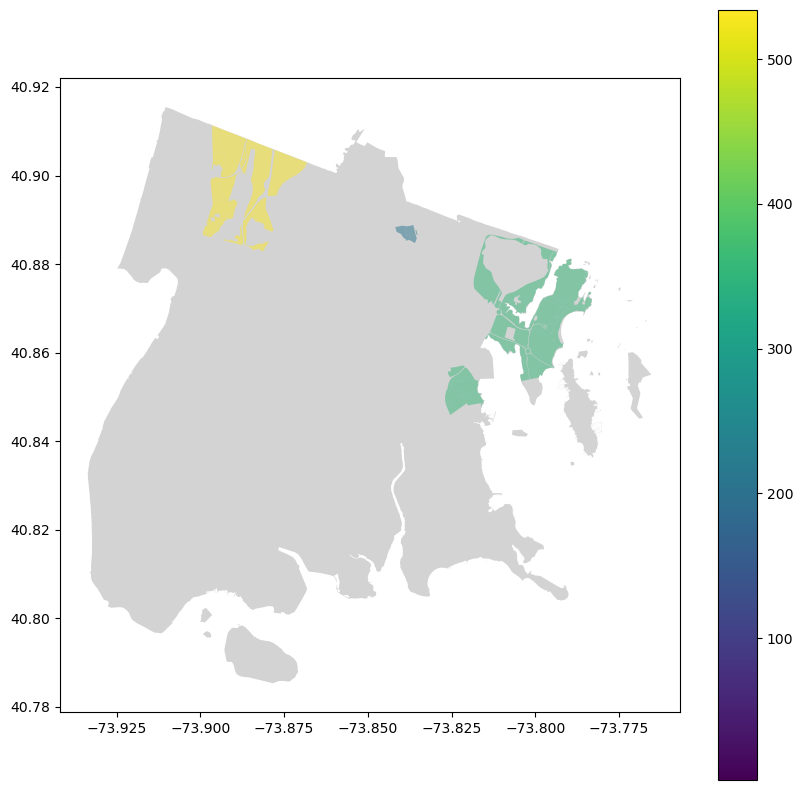

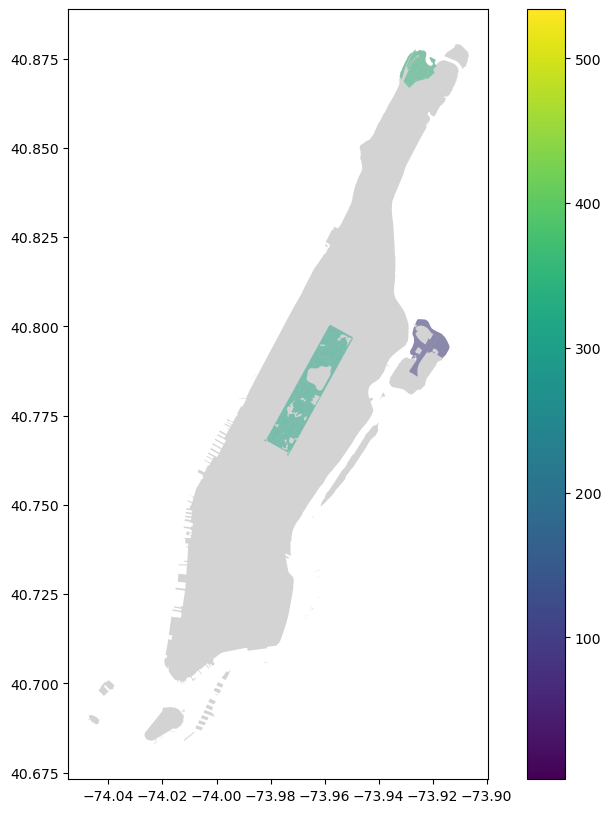

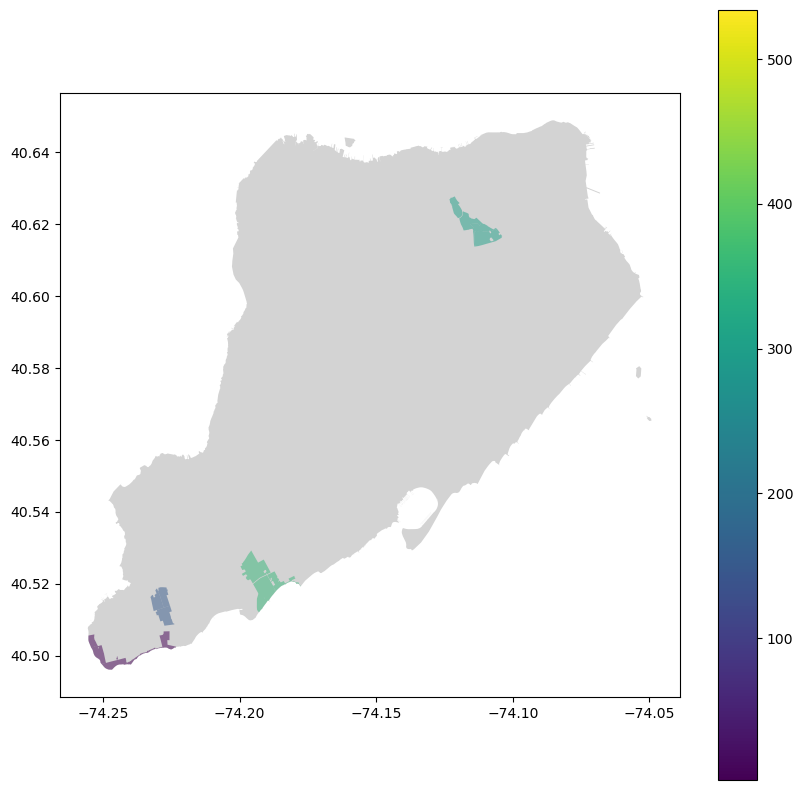

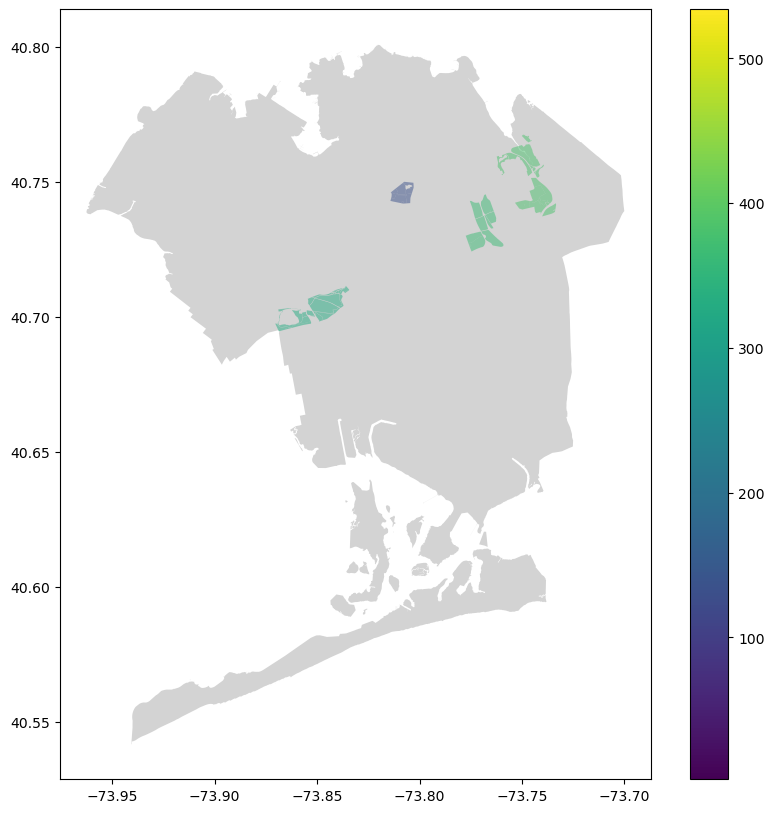

In [11]:
for b, boro in PARKS_MAPPING.items():
    fig, ax = plt.subplots(figsize=(10,10))
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax, legend=True, 
                                                alpha=.5, vmin=parks_viz['SpeciesCounts'].min(),
                                                vmax=parks_viz['SpeciesCounts'].max())
    # print(ax._children[1].__dict__)
    # print(ax.__dict__)
    # print(dir(ax))
;

''

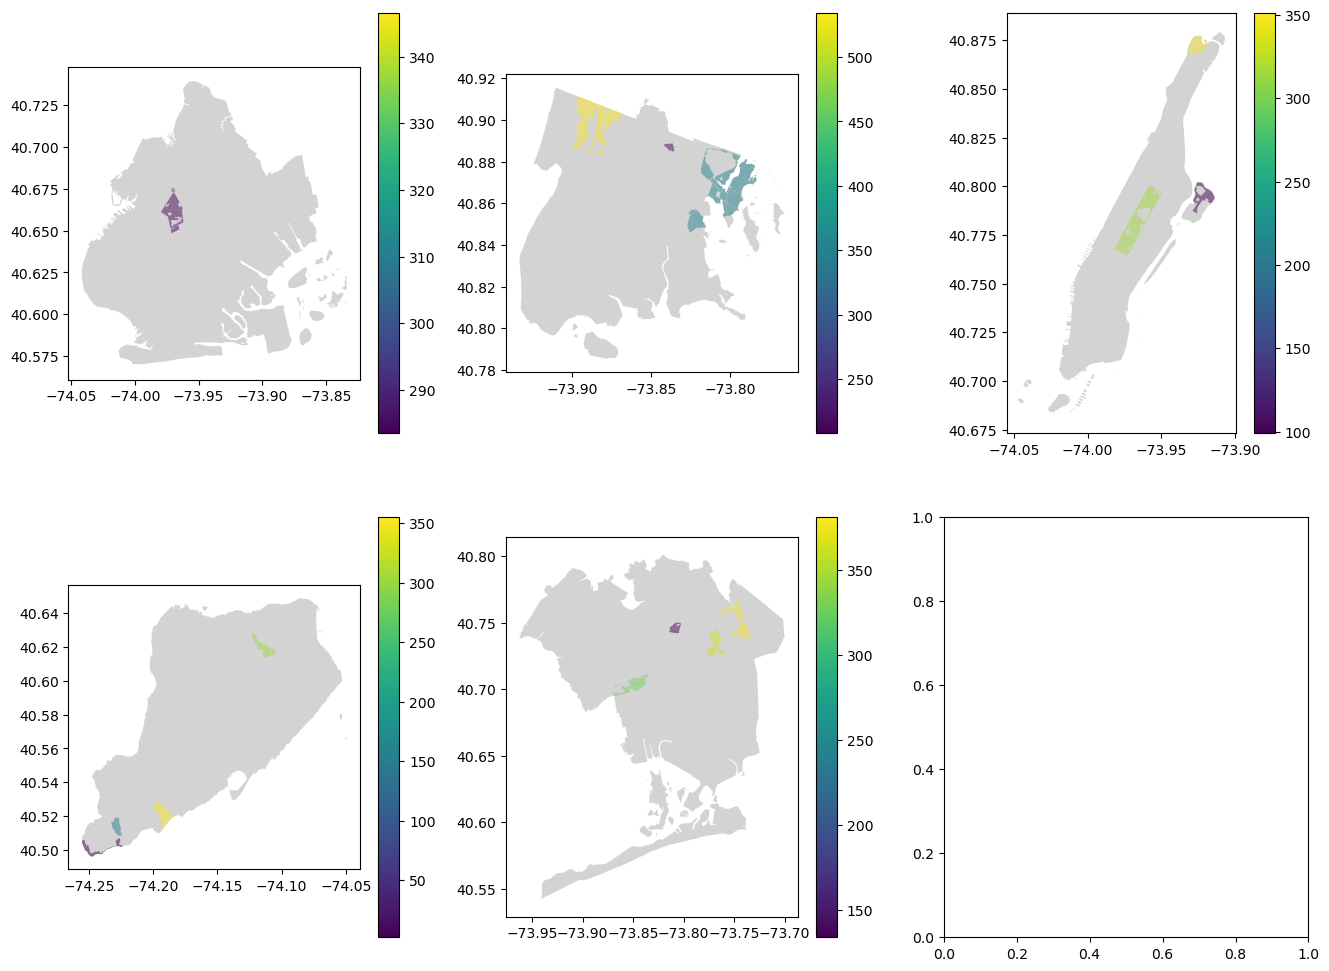

In [12]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax,
                  legend=True, alpha=.5)
;

In [13]:
boroughs.loc[boroughs['boro_name']=='Brooklyn']

,boro_code,boro_name,shape_area,shape_leng,geometry
0,3.0,Brooklyn,1.934143e+09,728147.130565,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."


In [14]:
parks_viz.sample(20)

,acres,borough,communityb,councildis,department,descriptio,gispropnum,location,nys_assemb,nys_senate,omppropid,precinct,propname,retired,retireddat,sitename,subcategor,us_congres,zipcode,geometry,ParkName,BroadGroupCounts,SpeciesCounts
770,75.486501,X,228.0,13.0,X-15A,Pelham Bay Park-Orchard Beach Parking Lot,X039,(w) Pk Dr To (n) Canoe Kayak Launch To (e) Orc...,82,34,X039-ZN11,45.0,Pelham Bay Park,F,None,None,None,14,1.046400e+04,"MULTIPOLYGON (((-73.79401 40.86841, -73.79415 ...",Pelham Bay Park,16.0,354.0
5,13.113413,M,164.0,6.0,M-13,Central Park West,M010,"66 St To 72 St, CPW To West Drive","67, 75",29,M010-ZN09,22.0,Central Park,F,None,None,None,10,1.002300e+04,"POLYGON ((-73.97607 40.77382, -73.97623 40.773...",Central Park,14.0,316.0
514,55.443317,X,228.0,13.0,X-15,Pelham Bay Park-Rodman's Neck East,X039,(n) City Island Rd. To (w) Park Dr. To (s) Pol...,82,34,X039-ZN09,2.0,Pelham Bay Park,F,None,None,None,14,1.046400e+04,"MULTIPOLYGON (((-73.79700 40.85749, -73.79695 ...",Pelham Bay Park,16.0,354.0
848,120.222008,R,503.0,51.0,R-03,Blue Heron Park Preserve-Blue Heron Park Zone 2,R119,"Amboy Rd, Barclay Av, Raritan Bay, Poillon Ave",62,24,R119-ZN02,123.0,Blue Heron Park,F,None,None,None,11,1.031200e+04,"MULTIPOLYGON (((-74.17423 40.53629, -74.17421 ...",NaN,NaN,NaN
614,40.953772,X,226.0,11.0,X-13,Van Cortlandt Park-Vault Hill,X092,Henry Hudson Pkwy To (s) Burial Vault,81,34,X092-ZN18,50.0,Van Cortlandt Park,F,None,None,None,16,1.047100e+04,"POLYGON ((-73.88740 40.90055, -73.88735 40.900...",Van Cortlandt Park,19.0,534.0
363,28.214365,X,226.0,11.0,X-13,Van Cortlandt Park-Indian Memorial To Indian F...,X092,Van Cortlandt Park East To Jerome Ave To East ...,81,34,X092-ZN11,3.0,Van Cortlandt Park,F,None,None,None,16,1.047000e+04,"POLYGON ((-73.87879 40.90000, -73.87878 40.900...",Van Cortlandt Park,19.0,534.0
310,0.936795,Q,412.0,28.0,Q-12,Baisley Pond Park-Sutphin Playground,None,Sutphin Blvd & 125 Ave,32,10,Q005-01,113.0,Baisley Pond Park,F,None,None,None,5,1.143400e+04,"POLYGON ((-73.78958 40.67496, -73.78955 40.674...",NaN,NaN,NaN
446,13.901654,Q,407.0,19.0,Q-07A,Fort Totten Park Zone 1,Q458,"Gen Berry, Shore, Ordnance Rds, Visitor Ctr, N...",26,11,Q458-ZN01,109.0,Fort Totten Park,F,None,None,None,3,1.135900e+04,"POLYGON ((-73.77281 40.79039, -73.77280 40.790...",NaN,NaN,NaN
518,5.636548,X,204.0,8.0,X-04,Macombs Dam Park Zone 3,X030,Sedgwick To Anderson Aves Along Jerome Ave,"77, 84",29,X030-ZN03,44.0,Macombs Dam Park,F,None,None,None,15,1.045200e+04,"MULTIPOLYGON (((-73.92874 40.82926, -73.92876 ...",NaN,NaN,NaN
308,9.018610,Q,414.0,32.0,Q-14,Rockaway Beach & Boardwalk-Rockaway Beach 10b,Q164,Btwn 130th And 134th St,23,15,Q164-ZN10B,100.0,Rockaway Beach,F,None,None,None,5,1.169400e+04,"POLYGON ((-73.85051 40.57181, -73.85083 40.572...",NaN,NaN,NaN


## Normalizing the data

Showing the number of species per park isn't super helpful since some parks are visited far more often than others. Let's try plotting the number of species *per walk*.

In [15]:
dfs = read_all_csvs('./data')
print(dfs.keys())

[*] Reading in Parks.csv...
[*] Reading in BroadGroups.csv...
[*] Reading in Parks_Properties_20241008.csv...
[*] Reading in Mushroom.csv...
[*] Reading in Walks.csv...
[*] Reading in Observations.csv...
dict_keys(['parks', 'broadgroups', 'parks_properties_20241008', 'mushroom', 'walks', 'observations'])


In [16]:
walk_counts = (dfs['walks']
               .groupby('ParkID')
               .count()[['WalkID']]
               .rename(columns={'WalkID':'WalkCounts'})
               .merge(dfs['parks'][['ParkID','ParkName']], on='ParkID')
              )
walk_counts.head()

,ParkID,WalkCounts,ParkName
0,11,47,Pelham Bay Park
1,12,33,High Rock Park
2,13,49,Prospect Park
3,14,11,Seton Falls Park
4,15,7,Kissena Park


In [17]:
parks_counts = parks_counts.merge(walk_counts, on='ParkName')
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts,ParkID,WalkCounts
0,Alley Pond Park,16,381,29,25
1,Beech Brook,17,386,30,8
2,Central Park,14,316,19,43
3,Clove Lakes Park,15,302,20,19
4,Collis P. Huntingdon Park,14,246,45,4
5,Conference House Park,2,2,43,1
6,Cunningham Park,15,364,26,37
7,Depew Park,12,185,35,5
8,Devil's Den Preserve,11,128,36,1
9,Fahnestock State Park,13,159,31,2


In [22]:
parks_counts['SpeciesPerWalk'] = parks_counts.apply(lambda x: round(x['SpeciesCounts']/x['WalkCounts'], 2), axis=1)
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts,ParkID,WalkCounts,SpeciesPerWalk
0,Alley Pond Park,16,381,29,25,15.24
1,Beech Brook,17,386,30,8,48.25
2,Central Park,14,316,19,43,7.35
3,Clove Lakes Park,15,302,20,19,15.89
4,Collis P. Huntingdon Park,14,246,45,4,61.50
5,Conference House Park,2,2,43,1,2.00
6,Cunningham Park,15,364,26,37,9.84
7,Depew Park,12,185,35,5,37.00
8,Devil's Den Preserve,11,128,36,1,128.00
9,Fahnestock State Park,13,159,31,2,79.50


In [19]:
parks_viz = parks_viz.merge(parks_counts[['SpeciesPerWalk','WalkCounts','ParkName']], 
                            left_on='propname', right_on='ParkName', 
                            how='left').drop(['ParkName_x','ParkName_y'],axis=1)
parks_viz.head()

,acres,borough,communityb,councildis,department,descriptio,gispropnum,location,nys_assemb,nys_senate,omppropid,precinct,propname,retired,retireddat,sitename,subcategor,us_congres,zipcode,geometry,BroadGroupCounts,SpeciesCounts,SpeciesPerWalk,WalkCounts
0,12.455131,M,164.0,6.0,M-13,Central Park-The Great Hill,M010,"N Of 105, E Of CPW, W Of West Dr, SE Of 106 Path",68,29,M010-ZN46,22.0,Central Park,F,None,None,None,13,10025.0,"POLYGON ((-73.95686 40.79685, -73.95683 40.796...",14.0,316.0,7.35,43.0
1,19.992587,M,164.0,6.0,M-13,Central Park-East Meadow,M010,"East Drive, 97 St Transverse, 5 Ave, E 102 St ...","69, 68",29,M010-ZN38,22.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.95386 40.79063, -73.95389 40.790...",14.0,316.0,7.35,43.0
2,6.451369,M,164.0,6.0,M-13,Central Park-North Meadow Recreation Center,M010,"W Drive, 97 St Transverse, N Meadow Recreation...","69, 68",29,M010-ZN36,2.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.96174 40.79158, -73.96172 40.791...",14.0,316.0,7.35,43.0
3,15.300478,M,164.0,6.0,M-13,Central Park-79th St Yard And Summit Rock,M010,"CPW, 79 St Transverse, West Drive To 85 St","69, 67",29,M010-ZN29,2.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96932 40.78429, -73.96926 40.784...",14.0,316.0,7.35,43.0
4,5.212581,M,164.0,6.0,M-13,Central Park-Reservoir Running Track & Landscape,M010,Mid-park In The 80's,69,29,M010-ZN31,4.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96320 40.78286, -73.96325 40.782...",14.0,316.0,7.35,43.0


''

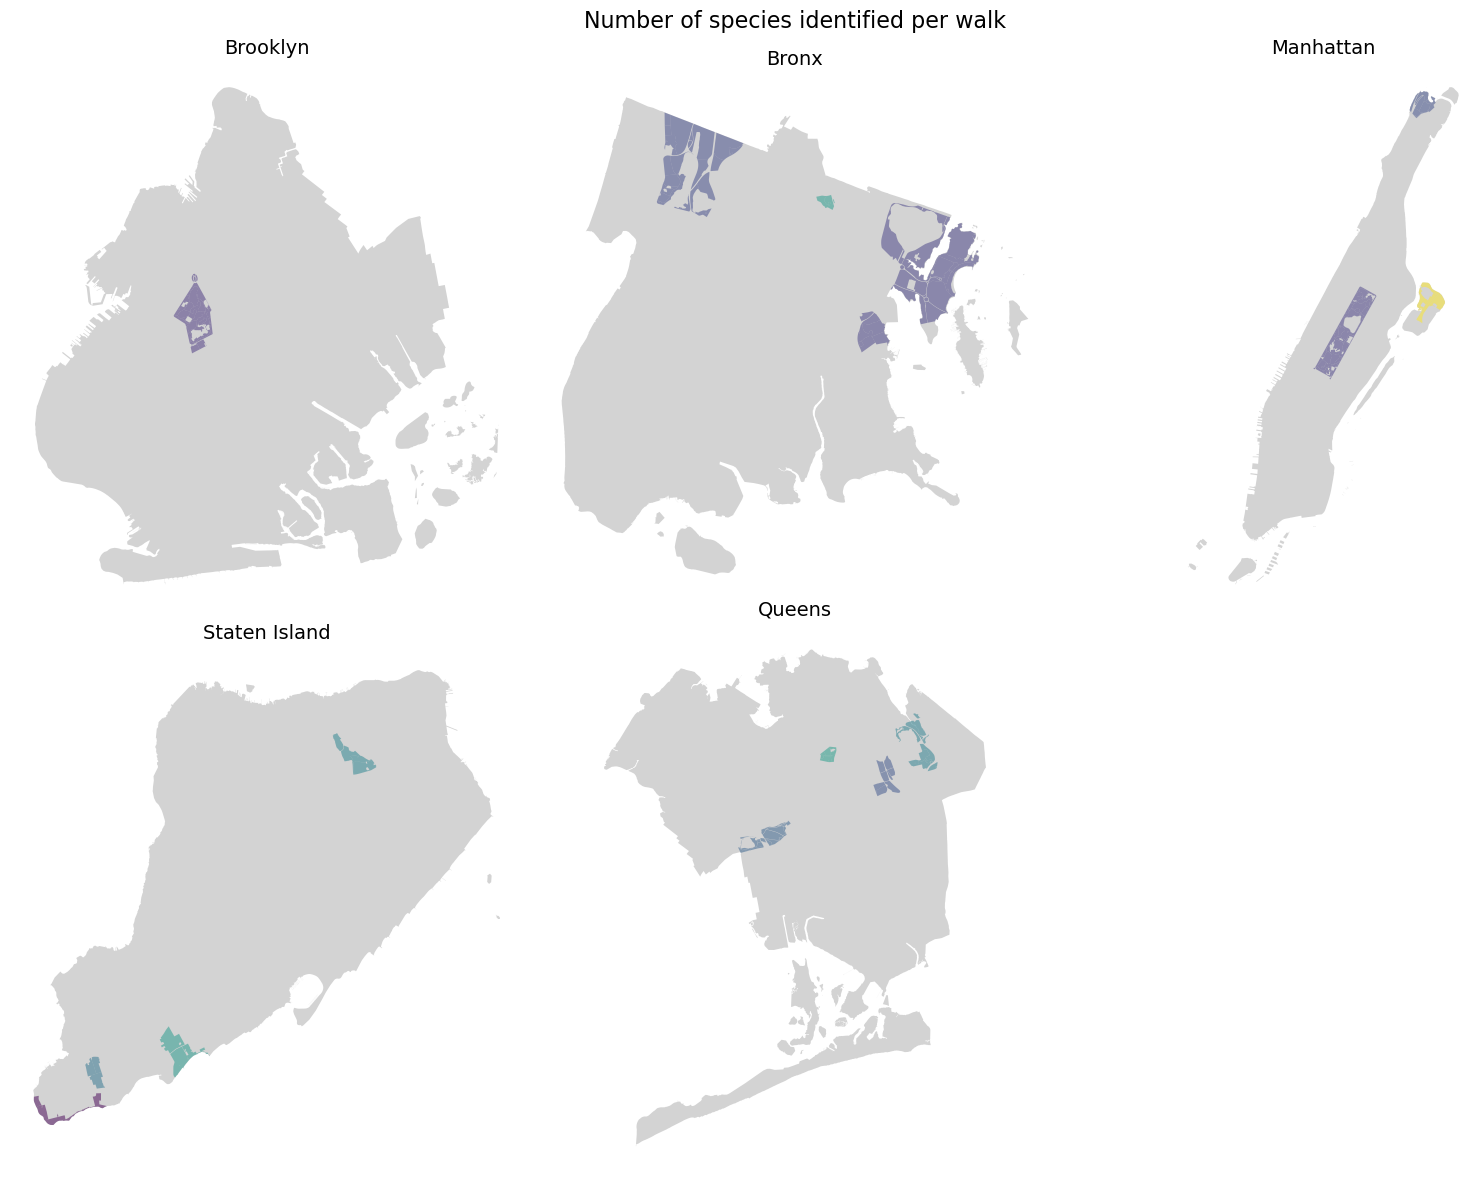

In [20]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesPerWalk', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['SpeciesPerWalk'].min(),
                                                vmax=parks_viz['SpeciesPerWalk'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Number of species identified per walk', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_species_per_walk.png')
;

''

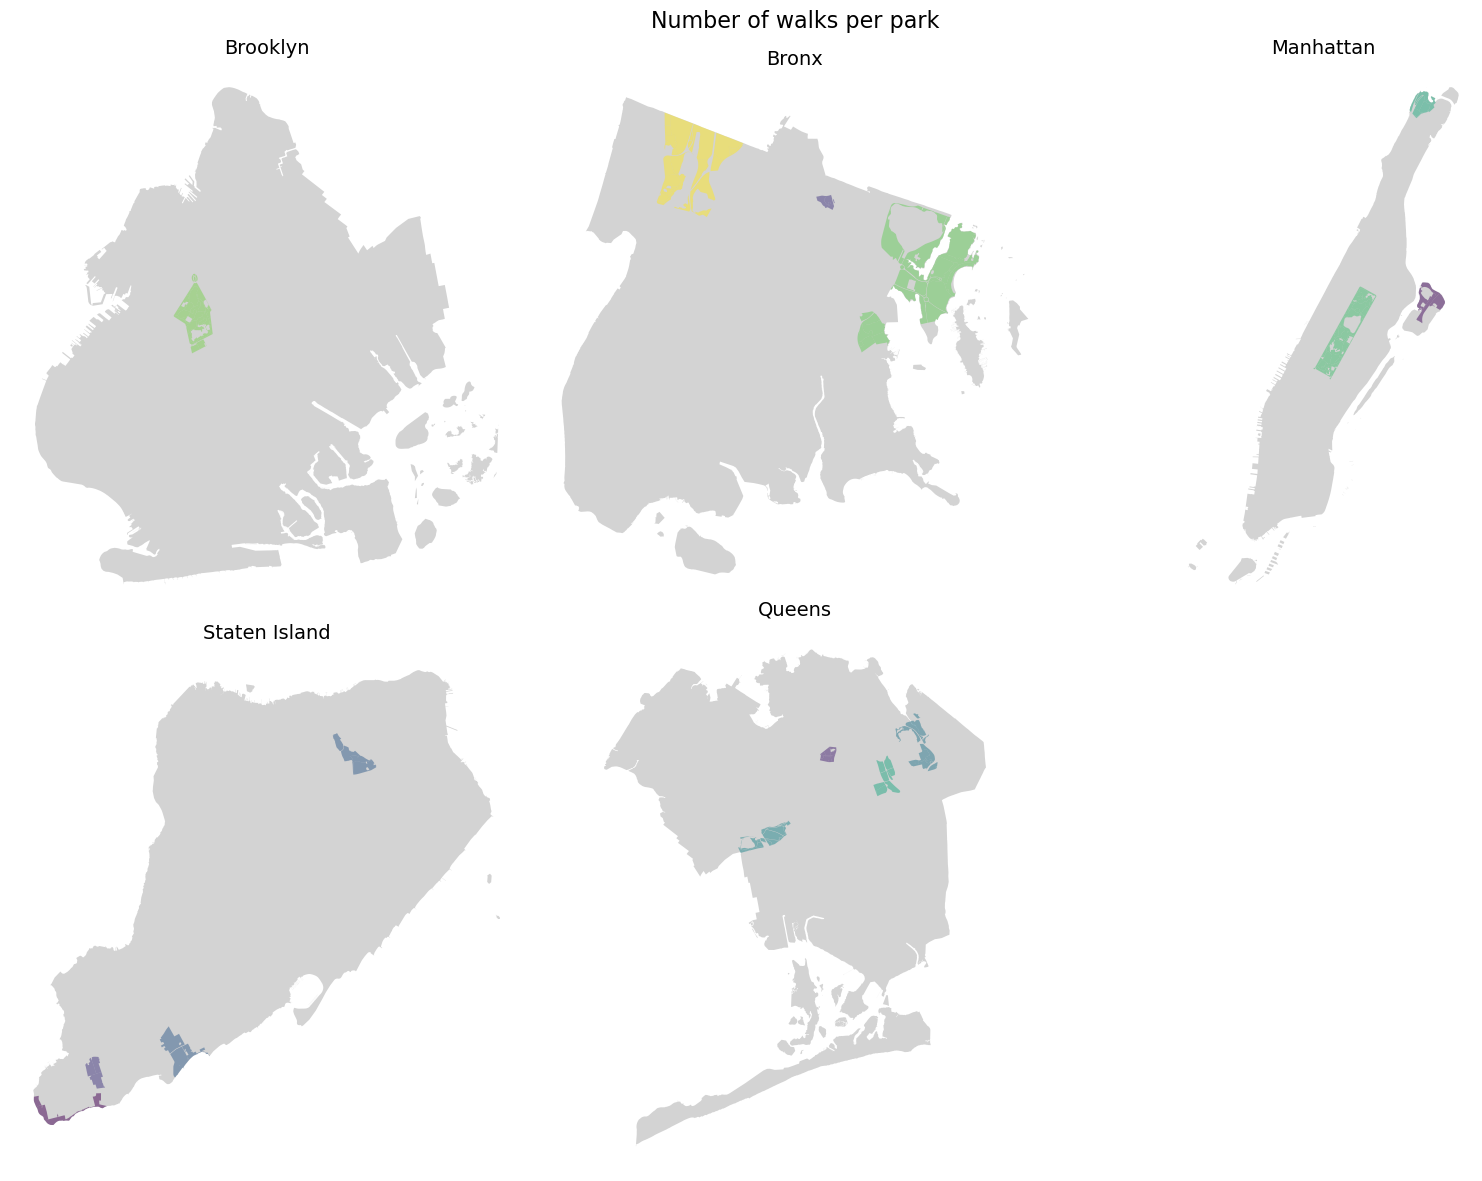

In [21]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='WalkCounts', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['WalkCounts'].min(),
                                                vmax=parks_viz['WalkCounts'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Number of walks per park', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_walks_per_park.png')
;